In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
of_activity = pd.read_csv("/Users/betsyfrdmn/Desktop/Lucas Code/CSV/OF_Activity.csv")
of_location = pd.read_csv("/Users/betsyfrdmn/Desktop/Lucas Code/CSV/OF_Locations.csv")
of_products = pd.read_csv("/Users/betsyfrdmn/Desktop/Lucas Code/CSV/OF_Products.csv")

In [3]:
of_activity["Timestamp"] = pd.to_datetime(of_activity["Timestamp"])
of_activity = of_activity.dropna(subset=["ProductID","Quantity","LocationID"])
of_activity["ProductID"] = of_activity["ProductID"].astype("Int64")
of_activity["LocationID"] = of_activity["LocationID"].astype("Int64")
of_activity["pick_time_sec"] = (
    of_activity.groupby("AssignmentID")["Timestamp"]
      .diff()
      .dt.total_seconds()
) 
of_activity["Hour"] = of_activity["Timestamp"].dt.hour

In [4]:
print(of_activity.head())
print(of_location.head())
print(of_products.head())

  ActivityCode  UserID  WorkCode  AssignmentID  ProductID  Quantity  \
0      PickPut     925        20       8202090      28572       1.0   
1      PickPut     925        20       8202091      28572       1.0   
2      PickPut     925        20       8202092      28572       1.0   
3      PickPut     925        20       8202093      28572       1.0   
4      PickPut     925        20       8202094      28572       1.0   

                Timestamp  LocationID  pick_time_sec  Hour  
0 2025-11-10 09:21:10.613      193775            NaN     9  
1 2025-11-10 09:21:23.520      193775            NaN     9  
2 2025-11-10 09:21:50.800      193775            NaN     9  
3 2025-11-10 09:22:15.090      193775            NaN     9  
4 2025-11-10 09:22:46.823      193775            NaN     9  
   LocationID       Aisle   Bay  Level  Slot
0           1          26  20.0    3.0   2.0
1           2          26  44.0    2.0   1.0
2           3  MANUAL PCK   NaN    NaN   NaN
3           4          42  

In [5]:
combined = of_activity.merge(of_location, 
                             on="LocationID", 
                             how="left").merge(of_products,
                                               on="ProductID",
                                               how="left")

In [6]:
combined.sort_values(by=["Timestamp"])

,ActivityCode,UserID,WorkCode,AssignmentID,ProductID,Quantity,Timestamp,LocationID,pick_time_sec,Hour,...,Bay,Level,Slot,ProductCode,UnitOfMeasure,Weight,Cube,Length,Width,Height
94234,PickPut,899,10,7786482,37846,5.0,2025-09-06 03:17:28.263,14852,NaN,3,...,45.0,4.0,1.0,6034TX990203,EA,0.31,0.031,NaN,NaN,NaN
94235,PickPut,899,10,7786483,53145,10.0,2025-09-06 03:27:36.170,150637,NaN,3,...,17.0,5.0,2.0,460001243A,CS,1.38,0.330,NaN,NaN,NaN
94236,PickPut,899,10,7786483,41453,5.0,2025-09-06 03:31:35.690,244318,239.520,3,...,46.0,2.0,1.0,4352SC096CHG,PK,0.05,0.001,NaN,NaN,NaN
94237,PickPut,899,10,7786483,20168,2.0,2025-09-06 03:33:11.903,13720,96.213,3,...,35.0,3.0,5.0,6783OFT081HP,CS,1.65,0.230,NaN,NaN,NaN
94238,PickPut,899,10,7786483,43643,1.0,2025-09-06 03:39:41.473,3445979,389.570,3,...,13.0,7.0,4.0,0158252200,CA,2.15,0.326,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94229,PickPut,788,20,8354432,7143,1.0,2025-12-03 10:39:00.523,57167,NaN,10,...,23.0,2.0,1.0,3642049235,CS,5.10,1.221,NaN,NaN,NaN
94230,PickPut,788,20,8354433,7143,1.0,2025-12-03 10:39:01.010,57167,NaN,10,...,23.0,2.0,1.0,3642049235,CS,5.10,1.221,NaN,NaN,NaN
94231,PickPut,788,20,8354434,7143,1.0,2025-12-03 10:39:01.470,57167,NaN,10,...,23.0,2.0,1.0,3642049235,CS,5.10,1.221,NaN,NaN,NaN
94232,PickPut,788,20,8354435,7143,1.0,2025-12-03 10:39:02.050,57167,NaN,10,...,23.0,2.0,1.0,3642049235,CS,5.10,1.221,NaN,NaN,NaN


1D EDA

In [7]:
combined.describe(include="all")

,ActivityCode,UserID,WorkCode,AssignmentID,ProductID,Quantity,Timestamp,LocationID,pick_time_sec,Hour,...,Bay,Level,Slot,ProductCode,UnitOfMeasure,Weight,Cube,Length,Width,Height
count,126808,126808.000000,126808.000000,1.268080e+05,126808.0,126808.000000,126808,126808.0,54500.000000,126808.000000,...,126808.000000,126808.000000,126808.000000,126582,126582,126582.000000,126582.000000,0.0,0.0,0.0
unique,1,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,...,NaN,NaN,NaN,7028,31,NaN,NaN,NaN,NaN,NaN
top,PickPut,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,...,NaN,NaN,NaN,072324200007,EA,NaN,NaN,NaN,NaN,NaN
freq,126808,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,...,NaN,NaN,NaN,2113,46028,NaN,NaN,NaN,NaN,NaN
mean,NaN,894.857746,25.739859,8.146439e+06,29357.984686,8.888177,2025-11-01 04:18:13.398730496,1538827.277766,603.765933,15.968188,...,23.490426,2.312315,2.317788,NaN,NaN,5.442953,0.527723,NaN,NaN,NaN
min,NaN,80.000000,10.000000,7.786482e+06,7.0,1.000000,2025-09-06 03:17:28.263000,1.0,-12869.517000,0.000000,...,1.000000,1.000000,1.000000,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,870.000000,20.000000,7.813101e+06,6708.0,1.000000,2025-09-09 22:09:05.497499904,917647.0,67.433750,13.000000,...,12.000000,1.000000,1.000000,NaN,NaN,0.159000,0.018000,NaN,NaN,NaN
50%,NaN,953.000000,30.000000,8.219546e+06,28610.0,2.000000,2025-11-12 10:24:05.840000,924880.0,302.980500,16.000000,...,21.000000,2.000000,2.000000,NaN,NaN,1.200000,0.128000,NaN,NaN,NaN
75%,NaN,981.000000,30.000000,8.335225e+06,48145.0,8.000000,2025-11-30 14:09:07.464999936,1881997.75,969.499750,19.000000,...,32.000000,3.000000,3.000000,NaN,NaN,7.000000,0.756000,NaN,NaN,NaN
max,NaN,1012.000000,30.000000,8.355057e+06,65494.0,2400.000000,2025-12-03 10:39:02.750000,8294777.0,17544.983000,23.000000,...,56.000000,11.000000,10.000000,NaN,NaN,539.000000,23.518000,NaN,NaN,NaN


In [8]:
combined.nunique()

ActivityCode          1
UserID               66
WorkCode              3
AssignmentID      72308
ProductID          9543
Quantity            221
Timestamp        126383
LocationID        10237
pick_time_sec     51359
Hour                 22
Aisle                49
Bay                  56
Level                11
Slot                 10
ProductCode        7028
UnitOfMeasure        31
Weight             2312
Cube               1947
Length                0
Width                 0
Height                0
dtype: int64

In [9]:
# How many pick tasks each user has

combined["UserID"].value_counts().head()

UserID
870    9006
947    6997
973    4845
969    4746
952    4494
Name: count, dtype: int64

<Axes: >

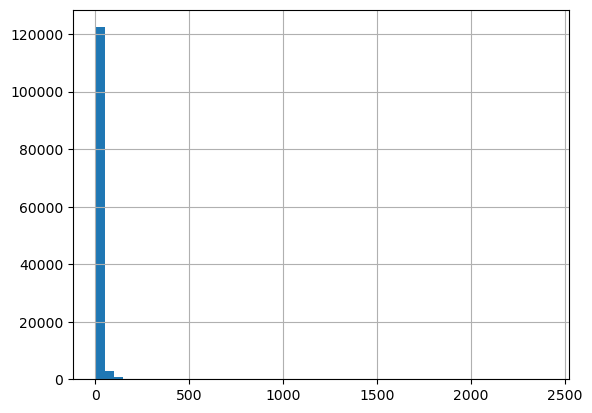

In [10]:
# Quantity Distribution
combined["Quantity"].hist(bins=50)

<Axes: >

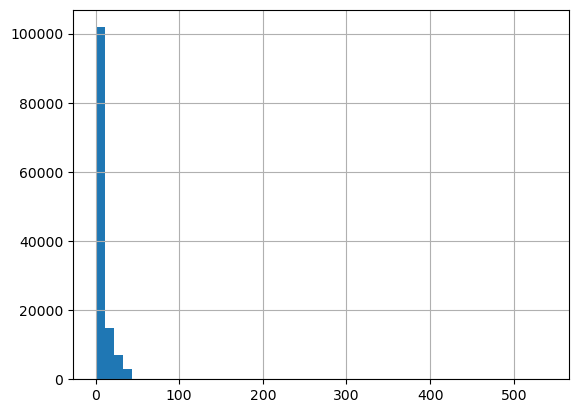

In [11]:
# Weight distribution
combined["Weight"].hist(bins=50)

<Axes: >

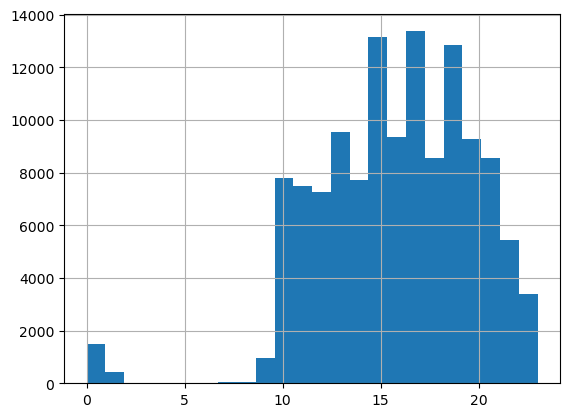

In [12]:
# Shows when the peak time is for picking
combined["hour"] = combined["Timestamp"].dt.hour
combined["hour"].hist(bins=24)

In [13]:
# Calculating pick time, filtering for those less than 10 minutes
combined = combined.sort_values(["UserID","Timestamp"])

combined["pick_time_sec"] = (
    combined.groupby("UserID")["Timestamp"]
      .diff()
      .dt.total_seconds()
)

combined_small = combined[combined["pick_time_sec"] < 600]

count    124333.000000
mean         59.665856
std          77.459952
min           0.143000
25%           3.527000
50%          37.620000
75%          79.383000
max         599.920000
Name: pick_time_sec, dtype: float64


<Axes: >

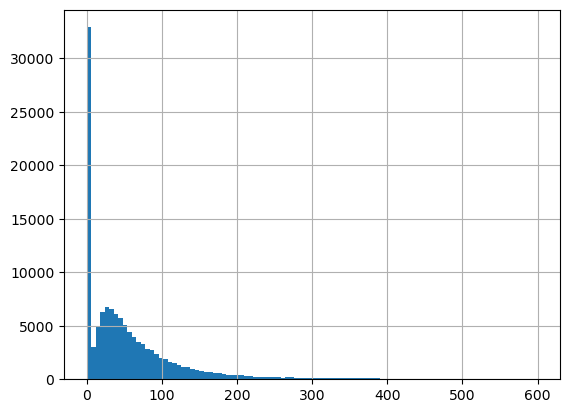

In [14]:
print(combined_small["pick_time_sec"].describe())
combined_small["pick_time_sec"].hist(bins=100)

#combined["pick_time_sec"].describe()
#combined["pick_time_sec"].hist(bins=50)

2D EDA

In [15]:
# Average pick times for each user
combined_small.groupby("UserID")["pick_time_sec"].mean().sort_values()

UserID
870      15.435080
947      18.625498
788      35.496735
911      44.338486
861      45.326025
           ...    
731     108.052414
934     108.949692
326     109.825991
1012    109.854190
458     121.035273
Name: pick_time_sec, Length: 66, dtype: float64

In [16]:
# Average pick times in each location
combined_small.groupby("LocationID")["pick_time_sec"].mean().sort_values()

LocationID
2032730      0.170000
10161        0.193000
1987195      0.195000
2023         0.196667
99988        0.205750
              ...    
2869383    588.464000
86392      591.254000
2015121    592.484000
10965      592.610000
1220724    598.784000
Name: pick_time_sec, Length: 10104, dtype: float64

In [17]:
# Average pick times in each aisle
combined_small.groupby("Aisle")["pick_time_sec"].mean().sort_values()

Aisle
29     22.246815
30     37.166181
53     53.129449
52     55.802984
71     56.023508
70     56.652601
27     58.520982
85     59.074598
74     59.669679
75     61.309856
88     61.587545
21     61.691032
73     62.068288
51     63.622150
72     65.146798
55     66.056913
23     66.276350
65     66.289082
32     66.289953
24     66.701464
26     68.078538
22     68.176515
31     68.601498
56     69.882694
20     70.539632
59     71.712308
57     72.002697
28     72.052630
25     73.519369
38     74.267123
54     75.488701
36     77.823987
37     85.784698
58     85.980250
86     87.919730
64     88.078925
19     89.055810
82     90.661091
43     91.996277
44     94.182474
42     97.040729
41     97.550096
83     98.741417
40    102.211048
39    104.699781
50    122.198045
87    128.541992
66    129.171704
84    136.910807
Name: pick_time_sec, dtype: float64

<Axes: xlabel='Hour'>

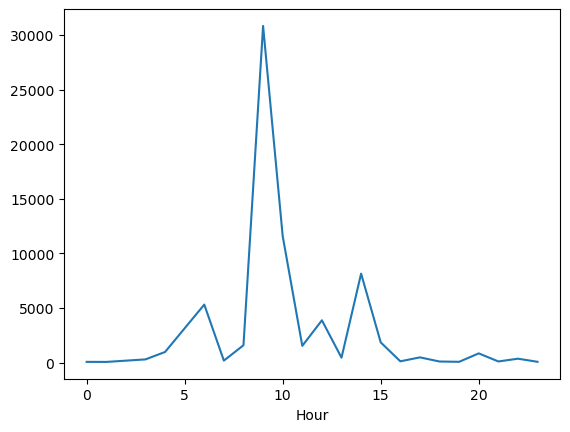

In [18]:
# Average speed for picking per hour
combined.groupby("Hour")["pick_time_sec"].mean().plot()

In [19]:
# Average speed for each weight range
# Watch out for negative weights...

combined_small.groupby(pd.cut(combined_small["Weight"], bins=20))["pick_time_sec"].mean()

/var/folders/r9/zx84vhy57q9_n8tk5dnw8g980000gn/T/ipykernel_1597/1585750222.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combined_small.groupby(pd.cut(combined_small["Weight"], bins=20))["pick_time_sec"].mean()


Weight
(-0.539, 26.95]     60.423439
(26.95, 53.9]       42.590892
(53.9, 80.85]      126.400000
(80.85, 107.8]            NaN
(107.8, 134.75]           NaN
(134.75, 161.7]           NaN
(161.7, 188.65]           NaN
(188.65, 215.6]           NaN
(215.6, 242.55]           NaN
(242.55, 269.5]           NaN
(269.5, 296.45]           NaN
(296.45, 323.4]           NaN
(323.4, 350.35]           NaN
(350.35, 377.3]           NaN
(377.3, 404.25]           NaN
(404.25, 431.2]           NaN
(431.2, 458.15]           NaN
(458.15, 485.1]           NaN
(485.1, 512.05]           NaN
(512.05, 539.0]    113.147200
Name: pick_time_sec, dtype: float64

In [20]:
# Average speed for each size range
# Watch out for negative sizes...

combined_small.groupby(pd.cut(combined_small["Cube"], bins=10))["pick_time_sec"].mean()


/var/folders/r9/zx84vhy57q9_n8tk5dnw8g980000gn/T/ipykernel_1597/4005658017.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combined_small.groupby(pd.cut(combined_small["Cube"], bins=10))["pick_time_sec"].mean()


Cube
(-0.0235, 2.352]     58.802493
(2.352, 4.704]       70.172010
(4.704, 7.055]       92.736926
(7.055, 9.407]      115.880078
(9.407, 11.759]            NaN
(11.759, 14.111]           NaN
(14.111, 16.463]           NaN
(16.463, 18.814]           NaN
(18.814, 21.166]           NaN
(21.166, 23.518]    113.147200
Name: pick_time_sec, dtype: float64

<Axes: xlabel='picks', ylabel='duration'>

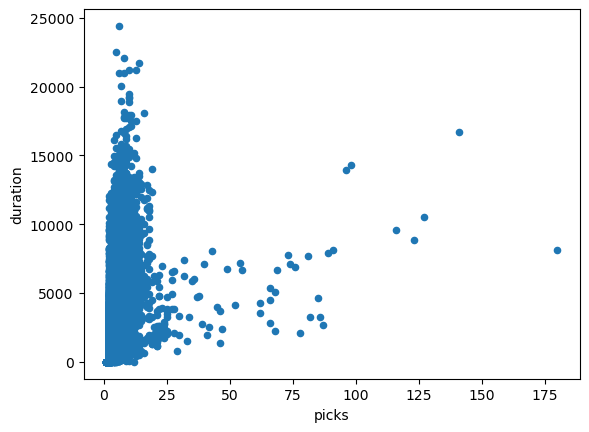

In [21]:
# Assignment number of picks vs duration

assignment = combined.groupby("AssignmentID").agg(
    picks=("ActivityCode","count"),
    duration=("Timestamp", lambda x: (x.max()-x.min()).total_seconds())
)

assignment.plot.scatter(x="picks", y="duration")


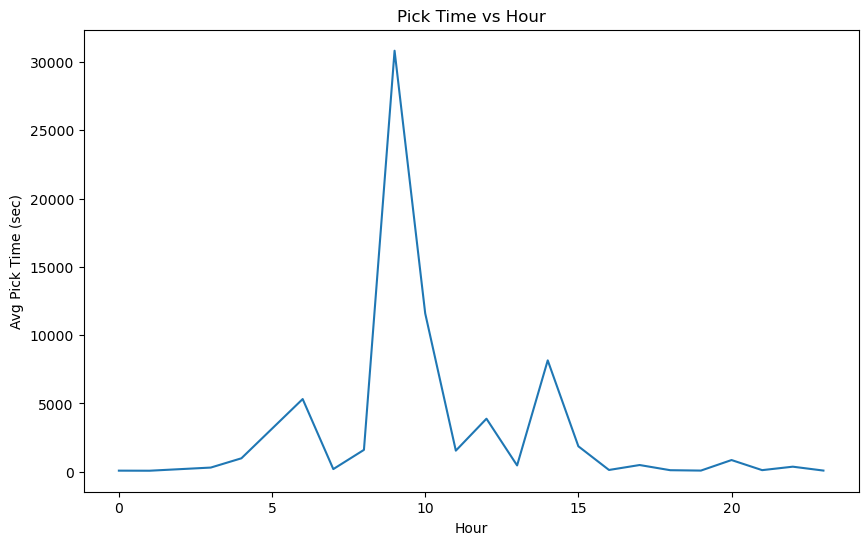

In [22]:
# Pick Time (in seconds) vs Hour

hourly = combined.groupby("Hour")["pick_time_sec"].mean()

plt.figure(figsize=(10,6))
plt.plot(hourly.index, hourly.values)
plt.xlabel("Hour")
plt.ylabel("Avg Pick Time (sec)")
plt.title("Pick Time vs Hour")
plt.show()


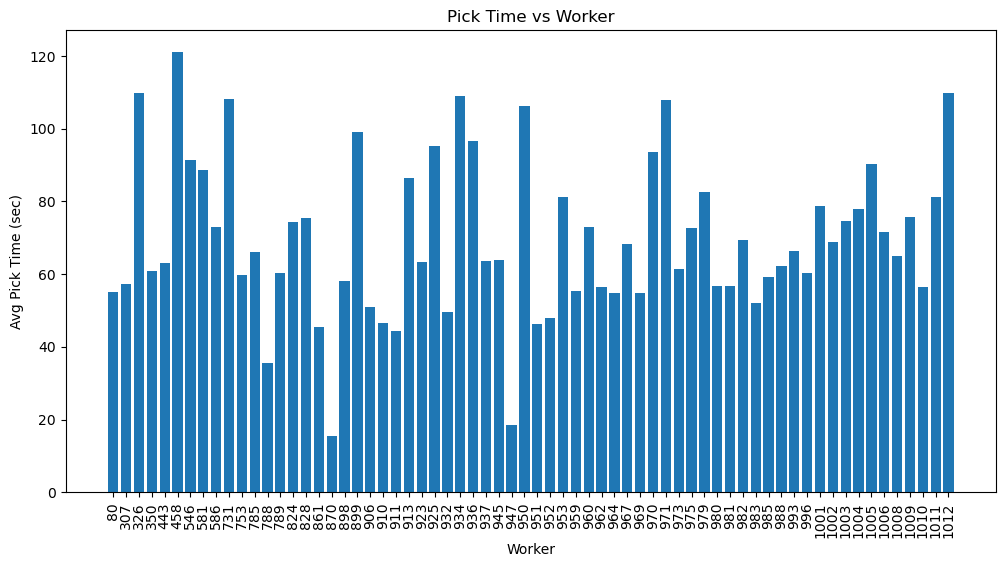

In [23]:
# Average Pick Time by Worker

worker = combined_small.groupby("UserID")["pick_time_sec"].mean()

plt.figure(figsize=(12,6))
plt.bar(worker.index.astype(str), worker.values)
plt.xticks(rotation=90)
plt.xlabel("Worker")
plt.ylabel("Avg Pick Time (sec)")
plt.title("Pick Time vs Worker")
plt.show()


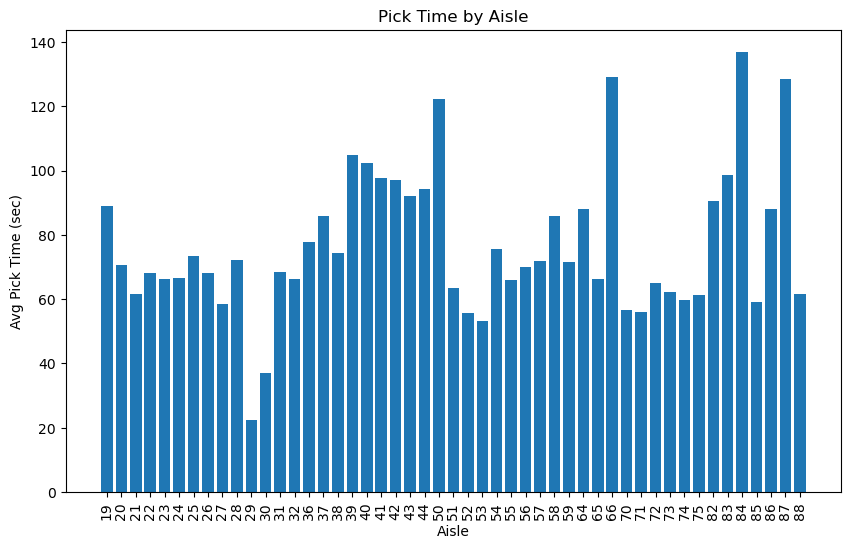

In [24]:
# Average Pick Time by Aisle

aisle = combined_small.groupby("Aisle")["pick_time_sec"].mean()

plt.figure(figsize=(10,6))
plt.bar(aisle.index.astype(str), aisle.values)
plt.xticks(rotation=90)
plt.xlabel("Aisle")
plt.ylabel("Avg Pick Time (sec)")
plt.title("Pick Time by Aisle")
plt.show()


/var/folders/r9/zx84vhy57q9_n8tk5dnw8g980000gn/T/ipykernel_1597/236602266.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weight_avg = tmp.groupby("weight_bin")["pick_time_sec"].mean()


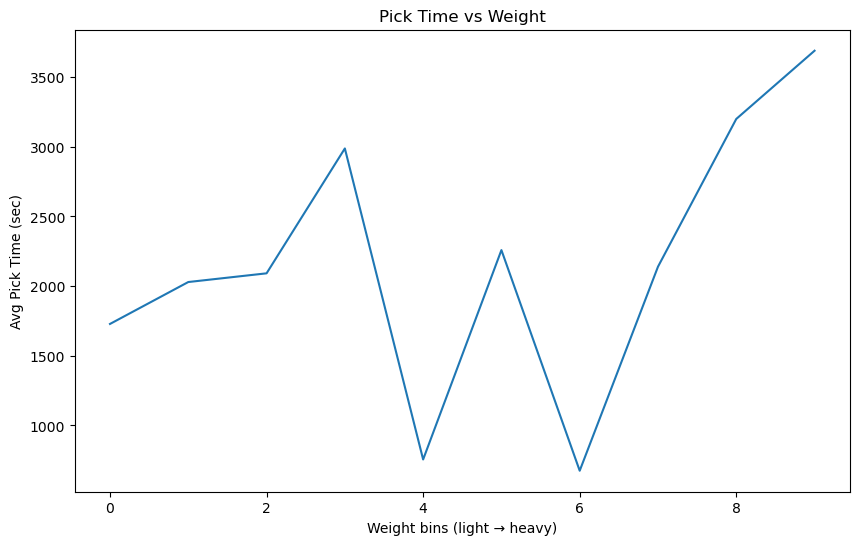

In [25]:
# Pick Time (in seconds) vs Weight
# Results are not as expected

tmp = combined.dropna(subset=["Weight"]).copy()

tmp["weight_bin"] = pd.qcut(tmp["Weight"], 10, duplicates="drop")
weight_avg = tmp.groupby("weight_bin")["pick_time_sec"].mean()

plt.figure(figsize=(10,6))
plt.plot(range(len(weight_avg)), weight_avg.values)
plt.xlabel("Weight bins (light → heavy)")
plt.ylabel("Avg Pick Time (sec)")
plt.title("Pick Time vs Weight")
plt.show()


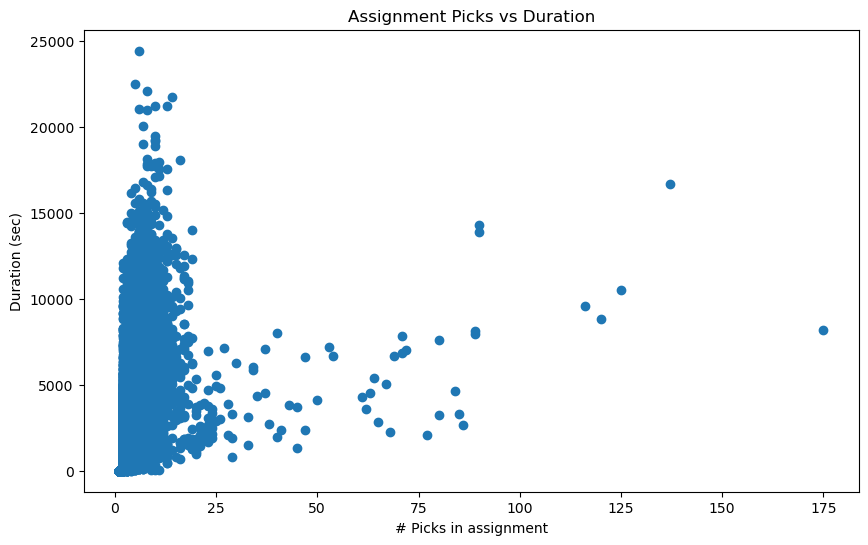

In [26]:
# Assignment Picks vs Duration

assign = (
    combined_small.groupby("AssignmentID")
      .agg(
          picks=("AssignmentID", "size"),
          duration=("Timestamp", lambda x: (x.max() - x.min()).total_seconds())
      )
)

plt.figure(figsize=(10,6))
plt.scatter(assign["picks"], assign["duration"])
plt.xlabel("# Picks in assignment")
plt.ylabel("Duration (sec)")
plt.title("Assignment Picks vs Duration")
plt.show()


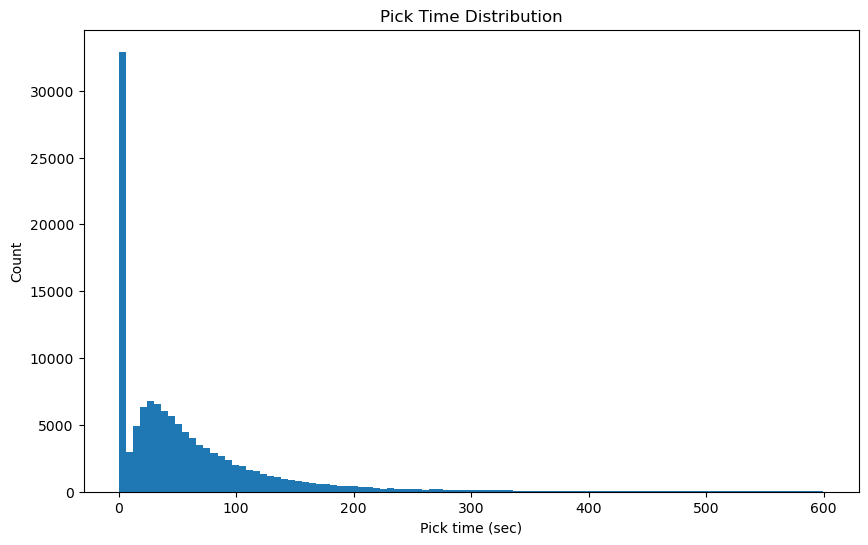

In [27]:
# Distribution of Pick Time

plt.figure(figsize=(10,6))
plt.hist(combined_small["pick_time_sec"], bins=100)
plt.xlabel("Pick time (sec)")
plt.ylabel("Count")
plt.title("Pick Time Distribution")
plt.show()


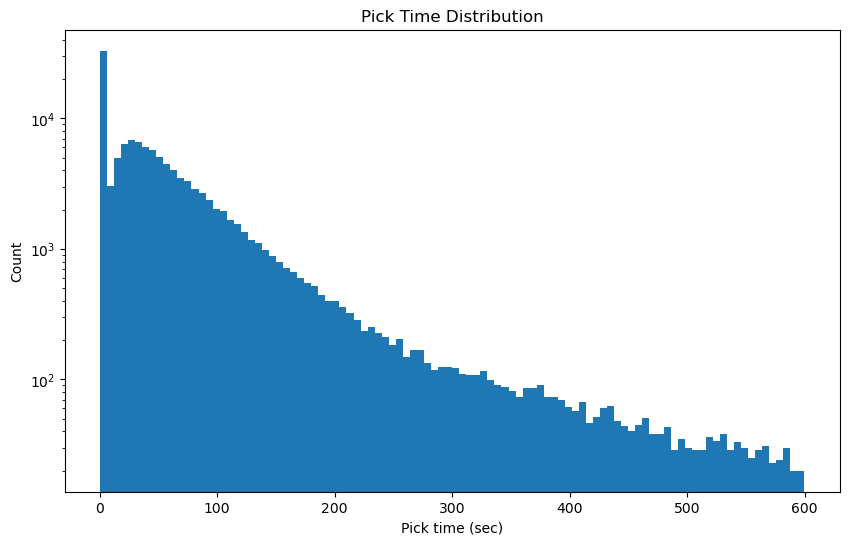

In [28]:
# Distribution of Pick Time after a Log Transformation

plt.figure(figsize=(10,6))
plt.hist(combined_small["pick_time_sec"], bins=100)
plt.xlabel("Pick time (sec)")
plt.ylabel("Count")
plt.title("Pick Time Distribution")
plt.yscale("log")
plt.show()


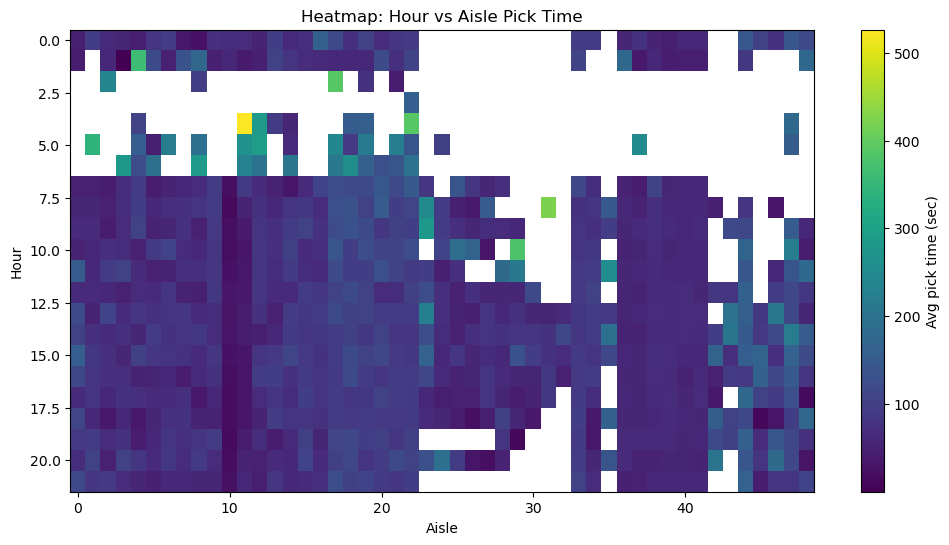

In [29]:
pivot = (
    combined_small.groupby(["hour", "Aisle"])["pick_time_sec"]
      .mean()
      .unstack()
)

plt.figure(figsize=(12,6))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="Avg pick time (sec)")
plt.xlabel("Aisle")
plt.ylabel("Hour")
plt.title("Heatmap: Hour vs Aisle Pick Time")
plt.show()


In [30]:
# Picks per worker

of_activity.groupby("UserID").size().sort_values(ascending=False)

UserID
870    9006
947    6997
973    4845
969    4746
952    4494
       ... 
350     103
934      69
458      57
785      36
937      18
Length: 66, dtype: int64

In [31]:
# Number of picks per aisle
combined.groupby("Aisle").size().sort_values(ascending=False)

Aisle
29    16344
70    15736
71    12633
74    11401
73    10745
75     7411
72     7280
30     4094
21     3309
64     3044
20     3009
22     2518
27     2321
26     1952
43     1631
44     1620
32     1477
28     1474
23     1447
39     1432
31     1385
40     1353
19     1311
36     1308
24     1283
37     1257
41     1242
25     1156
42     1105
65      693
38      652
52      452
84      384
51      357
88      275
53      257
50      245
54      234
55      197
56      185
87      126
85      110
86       89
57       67
82       57
58       56
83       54
66       27
59       13
dtype: int64

In [32]:
# Average

Hour
0      1502
1       447
3         8
4         4
6        13
7        41
8        45
9       972
10     7800
11     7505
12     7260
13     9553
14     7720
15    13168
16     9365
17    13370
18     8555
19    12834
20     9277
21     8547
22     5429
23     3393
dtype: int64


<Axes: xlabel='Hour'>

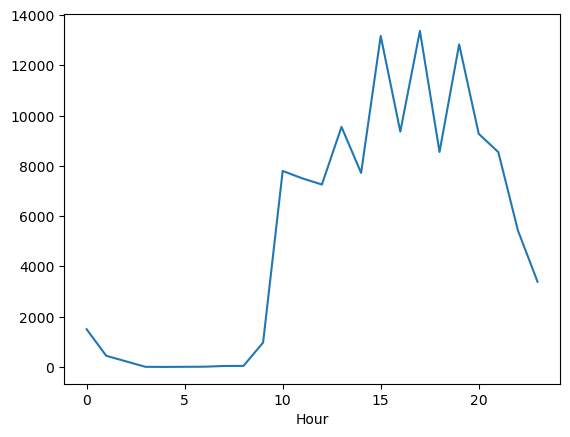

In [33]:
# Picks per hour
print(of_activity.groupby("Hour").size())
of_activity.groupby("Hour").size().plot()

In [34]:
# Time between picks

In [35]:
of_activity.groupby("UserID")["Timestamp"].diff()

0                           NaT
1        0 days 00:00:12.907000
2        0 days 00:00:27.280000
3        0 days 00:00:24.290000
4        0 days 00:00:31.733000
                  ...          
127402   0 days 00:01:18.236000
127403   0 days 00:01:46.710000
127404   0 days 00:00:58.173000
127405   0 days 00:01:05.193000
127406   0 days 00:00:17.440000
Name: Timestamp, Length: 126808, dtype: timedelta64[ns]

In [36]:
# Time between consecutive picks for the same worker
of_activity.groupby("UserID")["Timestamp"].min()

UserID
80     2025-09-08 21:11:23.960
307    2025-09-08 15:11:41.127
326    2025-09-08 14:24:54.880
350    2025-11-11 17:49:52.337
443    2025-09-07 09:14:30.737
                 ...          
1008   2025-11-10 12:13:55.667
1009   2025-11-11 21:46:03.997
1010   2025-11-10 14:20:18.213
1011   2025-11-12 20:58:13.990
1012   2025-12-01 13:13:27.460
Name: Timestamp, Length: 66, dtype: datetime64[ns]

In [37]:
of_activity.groupby("UserID")["Timestamp"].max()

UserID
80     2025-12-03 00:31:02.543
307    2025-12-02 20:53:53.080
326    2025-12-03 01:08:21.803
350    2025-11-12 20:12:29.660
443    2025-12-03 10:37:15.363
                 ...          
1008   2025-12-03 10:37:01.597
1009   2025-12-02 21:39:41.070
1010   2025-12-02 21:43:45.933
1011   2025-12-02 21:48:07.017
1012   2025-12-02 21:44:00.733
Name: Timestamp, Length: 66, dtype: datetime64[ns]

In [38]:
# Assignment duration
assignment = of_activity.groupby("AssignmentID").agg(
    picks=("ActivityCode","count"),
    duration=("Timestamp", lambda x: (x.max()-x.min()).total_seconds())
)


In [39]:
# Worker speed comparison
of_activity.groupby("UserID")["pick_time_sec"].mean().sort_values()


UserID
969    -155.920581
1003   -110.610750
824      59.459333
898      65.977024
307      86.238482
           ...    
789            NaN
870            NaN
906            NaN
910            NaN
985            NaN
Name: pick_time_sec, Length: 66, dtype: float64

In [40]:
of_location.head()

,LocationID,Aisle,Bay,Level,Slot
0,1,26,20.0,3.0,2.0
1,2,26,44.0,2.0,1.0
2,3,MANUAL PCK,NaN,NaN,NaN
3,4,42,40.0,3.0,1.0
4,5,44,28.0,5.0,5.0


In [41]:
# something is wrong with OF_Products, it is identical to OF_Locations

of_products.head()

,ProductID,ProductCode,UnitOfMeasure,Weight,Cube,Length,Width,Height
0,1,1638412011,BX,1.0,0.135,NaN,NaN,NaN
1,2,1638412012,BX,1.3,0.170,NaN,NaN,NaN
2,3,3583030454,BX,1.1,0.075,NaN,NaN,NaN
3,4,3583056102,CA,5.2,1.108,NaN,NaN,NaN
4,5,4509002244,CA,3.8,0.678,NaN,NaN,NaN


In [42]:
of_activity.info()

<class 'pandas.core.frame.DataFrame'>
Index: 126808 entries, 0 to 127406
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   ActivityCode   126808 non-null  object        
 1   UserID         126808 non-null  int64         
 2   WorkCode       126808 non-null  int64         
 3   AssignmentID   126808 non-null  int64         
 4   ProductID      126808 non-null  Int64         
 5   Quantity       126808 non-null  float64       
 6   Timestamp      126808 non-null  datetime64[ns]
 7   LocationID     126808 non-null  Int64         
 8   pick_time_sec  54500 non-null   float64       
 9   Hour           126808 non-null  int32         
dtypes: Int64(2), datetime64[ns](1), float64(2), int32(1), int64(3), object(1)
memory usage: 10.4+ MB


In [43]:
of_activity.describe(include="all")

,ActivityCode,UserID,WorkCode,AssignmentID,ProductID,Quantity,Timestamp,LocationID,pick_time_sec,Hour
count,126808,126808.000000,126808.000000,1.268080e+05,126808.0,126808.000000,126808,126808.0,54500.000000,126808.000000
unique,1,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN
top,PickPut,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN
freq,126808,NaN,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN
mean,NaN,894.857746,25.739859,8.146439e+06,29357.984686,8.888177,2025-11-01 04:18:13.398730496,1538827.277766,603.765933,15.968188
min,NaN,80.000000,10.000000,7.786482e+06,7.0,1.000000,2025-09-06 03:17:28.263000,1.0,-12869.517000,0.000000
25%,NaN,870.000000,20.000000,7.813101e+06,6708.0,1.000000,2025-09-09 22:09:05.497499904,917647.0,67.433750,13.000000
50%,NaN,953.000000,30.000000,8.219546e+06,28610.0,2.000000,2025-11-12 10:24:05.840000,924880.0,302.980500,16.000000
75%,NaN,981.000000,30.000000,8.335225e+06,48145.0,8.000000,2025-11-30 14:09:07.464999936,1881997.75,969.499750,19.000000
max,NaN,1012.000000,30.000000,8.355057e+06,65494.0,2400.000000,2025-12-03 10:39:02.750000,8294777.0,17544.983000,23.000000


In [44]:
of_activity.groupby("ProductID")["Quantity"].sum()

ProductID
7        3030.0
11       1279.0
12       2357.0
23       1257.0
25        600.0
          ...  
65490       2.0
65491       1.0
65492       1.0
65493       1.0
65494       1.0
Name: Quantity, Length: 9543, dtype: float64